# 주택 특성과 입지 특성을 활용한 서울 3개구 아파트 실거래가 예측
- 분석 대상: 강남구 / 노원구 / 성동구 (2023~2025년)
- 비교 모델: **Model A** (주택 특성만) vs **Model B** (주택 + 입지 특성)
- 사용 알고리즘: 선형회귀, 랜덤 포레스트

In [38]:
pip install jinja2

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [39]:
pip install seaborn scikit-learn matplotlib pandas numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. 라이브러리 로드 및 환경 설정

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

print('라이브러리 로드 완료')

라이브러리 로드 완료


## 2. 데이터 수집 및 로드
- 출처: 국토교통부 실거래가 공개시스템 (https://rt.molit.go.kr)
- 기간: 2023년 1월 ~ 2025년 12월
- 대상: 강남구 / 노원구 / 성동구 아파트 매매 실거래

In [41]:
BASE_PATH = 'E:/2026 3-1/DataMining_2026/teamproject/'

FILE_INFO = [
    ('2023_강남.csv', '강남구', 2023),
    ('2023_노원.csv', '노원구', 2023),
    ('2023_성동.csv', '성동구', 2023),
    ('2024_강남.csv', '강남구', 2024),
    ('2024_노원.csv', '노원구', 2024),
    ('2024_성동.csv', '성동구', 2024),
    ('2025_강남.csv', '강남구', 2025),
    ('2025_노원.csv', '노원구', 2025),
    ('2025_성동.csv', '성동구', 2025),
]

dfs = []
for fname, district, year in FILE_INFO:
    df = pd.read_csv(BASE_PATH + fname, encoding='cp949', skiprows=15, header=0, on_bad_lines='skip')
    df['자치구'] = district
    dfs.append(df)
    print(f'{fname}: {len(df):,}건 로드')

raw_df = pd.concat(dfs, ignore_index=True)
print(f'\n전체 데이터: {len(raw_df):,}건')
raw_df.head(3)

2023_강남.csv: 2,339건 로드
2023_노원.csv: 2,653건 로드
2023_성동.csv: 1,565건 로드
2024_강남.csv: 3,754건 로드
2024_노원.csv: 4,211건 로드
2024_성동.csv: 2,887건 로드
2025_강남.csv: 4,315건 로드
2025_노원.csv: 5,797건 로드
2025_성동.csv: 4,710건 로드

전체 데이터: 32,231건


,NO,시군구,번지,본번,부번,단지명,전용면적(㎡),계약년월,계약일,거래금액(만원),...,층,매수자,매도자,건축년도,도로명,해제사유발생일,거래유형,중개사소재지,등기일자,자치구
0,1.0,서울특별시 강남구 개포동,12,12.0,0.0,삼익대청아파트,60.00,202312.0,31.0,"162,500",...,8.0,-,-,1992.0,개포로109길 21,-,중개거래,서울 강남구,24.01.22,강남구
1,2.0,서울특별시 강남구 역삼동,757,757.0,0.0,역삼래미안,59.53,202312.0,31.0,"182,000",...,17.0,-,-,2005.0,선릉로69길 19,-,중개거래,서울 강남구,24.03.22,강남구
2,3.0,서울특별시 강남구 대치동,1027,1027.0,0.0,래미안대치팰리스,84.98,202312.0,30.0,"323,000",...,18.0,-,-,2015.0,삼성로51길 37,-,중개거래,서울 강남구,24.02.29,강남구


## 3. 데이터 전처리

In [42]:
df = raw_df.copy()

# 동 이름 추출 (시군구 컬럼 마지막 단어)
df['동명'] = df['시군구'].str.split().str[-1]

# 거래금액: 쉼표 제거 후 숫자 변환
df['거래금액(만원)'] = df['거래금액(만원)'].astype(str).str.replace(',', '').str.strip()
df['거래금액(만원)'] = pd.to_numeric(df['거래금액(만원)'], errors='coerce')

# 계약년월 결측 제거 후 년·월 추출
df['계약년월'] = pd.to_numeric(df['계약년월'], errors='coerce')
df = df.dropna(subset=['계약년월'])
df['계약년월'] = df['계약년월'].astype(int)
df['계약년'] = df['계약년월'] // 100
df['계약월'] = df['계약년월'] % 100

# 건물연식: 계약년 - 건축년도
df['건축년도'] = pd.to_numeric(df['건축년도'], errors='coerce')
df['건물연식'] = df['계약년'] - df['건축년도']

# 층: 음수(-1, -2 등 지하) 및 0층 제거
df['층'] = pd.to_numeric(df['층'], errors='coerce')
df = df[df['층'] > 0]

# 전용면적 숫자 변환
df['전용면적(㎡)'] = pd.to_numeric(df['전용면적(㎡)'], errors='coerce')

# 중개거래만 사용 (직거래는 시장 가격 반영 불완전)
df = df[df['거래유형'] == '중개거래']

# 해제 거래 제거 (해제사유발생일이 있으면 취소된 거래)
df = df[df['해제사유발생일'].isna() | (df['해제사유발생일'] == '-')]

# 결측치 제거 (핵심 컬럼)
core_cols = ['거래금액(만원)', '전용면적(㎡)', '층', '건물연식', '건축년도']
df = df.dropna(subset=core_cols)

# 이상치 제거: 전용면적 10㎡ 미만, 거래금액 1억 미만 제거
df = df[(df['전용면적(㎡)'] >= 10) & (df['거래금액(만원)'] >= 10000)]

# 건물연식 음수 제거 (신축 분양 전 사전 계약 등)
df = df[df['건물연식'] >= 0]

df = df.reset_index(drop=True)
print(f'전처리 후 데이터: {len(df):,}건')
print(f'\n자치구별 건수:')
print(df['자치구'].value_counts())

전처리 후 데이터: 29,018건

자치구별 건수:
자치구
노원구    11523
강남구     9374
성동구     8121
Name: count, dtype: int64


## 4. 변수 생성: 역세권 여부
- 지하철역 500m 내 위치 여부를 동(洞) 단위로 정의
- 국토교통부 지하철역 위치 및 서울시 지하철 노선도 기준으로 판단

| 자치구 | 역세권 동 | 비역세권 동 |
|--------|-----------|-------------|
| 강남구 | 개포동(3호선), 논현동(7호선), 대치동(3호선), 도곡동(3호선), 삼성동(2호선), 수서동(3호선), 신사동(3호선), 압구정동(3호선), 역삼동(2호선), 일원동(3호선), 청담동(7호선) | 세곡동, 율현동, 자곡동 (강남구 외곽, 역 없음) |
| 노원구 | 공릉동(경춘선), 상계동(4호선), 월계동(1호선), 중계동(4호선), 하계동(4호선) | 없음 |
| 성동구 | 금호동1~4가(5호선), 마장동(5호선), 상왕십리동(2·5호선), 성수동1·2가(2호선), 신당동(2·6호선), 옥수동(3호선), 용답동(2호선), 응봉동(경의중앙선), 하왕십리동(2·5호선), 행당동(5호선) | 도선동, 사근동, 송정동, 홍익동 |

In [43]:
# 역세권 동 목록 정의
STATION_AREA = {
    # 강남구: 외곽 3개 동 제외 나머지 역세권
    '개포동': 1, '논현동': 1, '대치동': 1, '도곡동': 1, '삼성동': 1,
    '수서동': 1, '신사동': 1, '압구정동': 1, '역삼동': 1, '일원동': 1, '청담동': 1,
    '세곡동': 0, '율현동': 0, '자곡동': 0,
    # 노원구: 전 지역 4호선/7호선/1호선 경유 → 모두 역세권
    '공릉동': 1, '상계동': 1, '월계동': 1, '중계동': 1, '하계동': 1,
    # 성동구: 주요 역 인근 동 역세권 처리
    '금호동1가': 1, '금호동2가': 1, '금호동3가': 1, '금호동4가': 1,
    '마장동': 1, '상왕십리동': 1, '성수동1가': 1, '성수동2가': 1,
    '신당동': 1, '옥수동': 1, '용답동': 1, '응봉동': 1,
    '하왕십리동': 1, '행당동': 1,
    '도선동': 0, '사근동': 0, '송정동': 0, '홍익동': 0,
}

df['역세권여부'] = df['동명'].map(STATION_AREA)

print('역세권 여부 분포:')
print(df.groupby('자치구')['역세권여부'].value_counts().unstack(fill_value=0))
print(f'\n전체 역세권: {df["역세권여부"].mean():.1%}')

역세권 여부 분포:
역세권여부    0      1
자치구              
강남구    658   8716
노원구      0  11523
성동구    177   7944

전체 역세권: 97.1%


## 5. 탐색적 데이터 분석 (EDA)

In [44]:
# 기초 통계
print('=== 기초 통계 ===\n')
summary = df.groupby('자치구')['거래금액(만원)'].agg(['count','mean','median','std','min','max'])
summary.columns = ['건수', '평균(만원)', '중앙값(만원)', '표준편차', '최솟값', '최댓값']
summary = summary.map(lambda x: f'{x:,.0f}' if isinstance(x, float) else x)
display(summary)

=== 기초 통계 ===



,건수,평균(만원),중앙값(만원),표준편차,최솟값,최댓값
자치구,,,,,,
강남구,9374,"257,546","229,850","152,488","14,000","1,900,000"
노원구,11523,"62,074","58,000","22,187","10,000","160,000"
성동구,8121,"150,388","138,000","84,042","12,000","2,900,000"


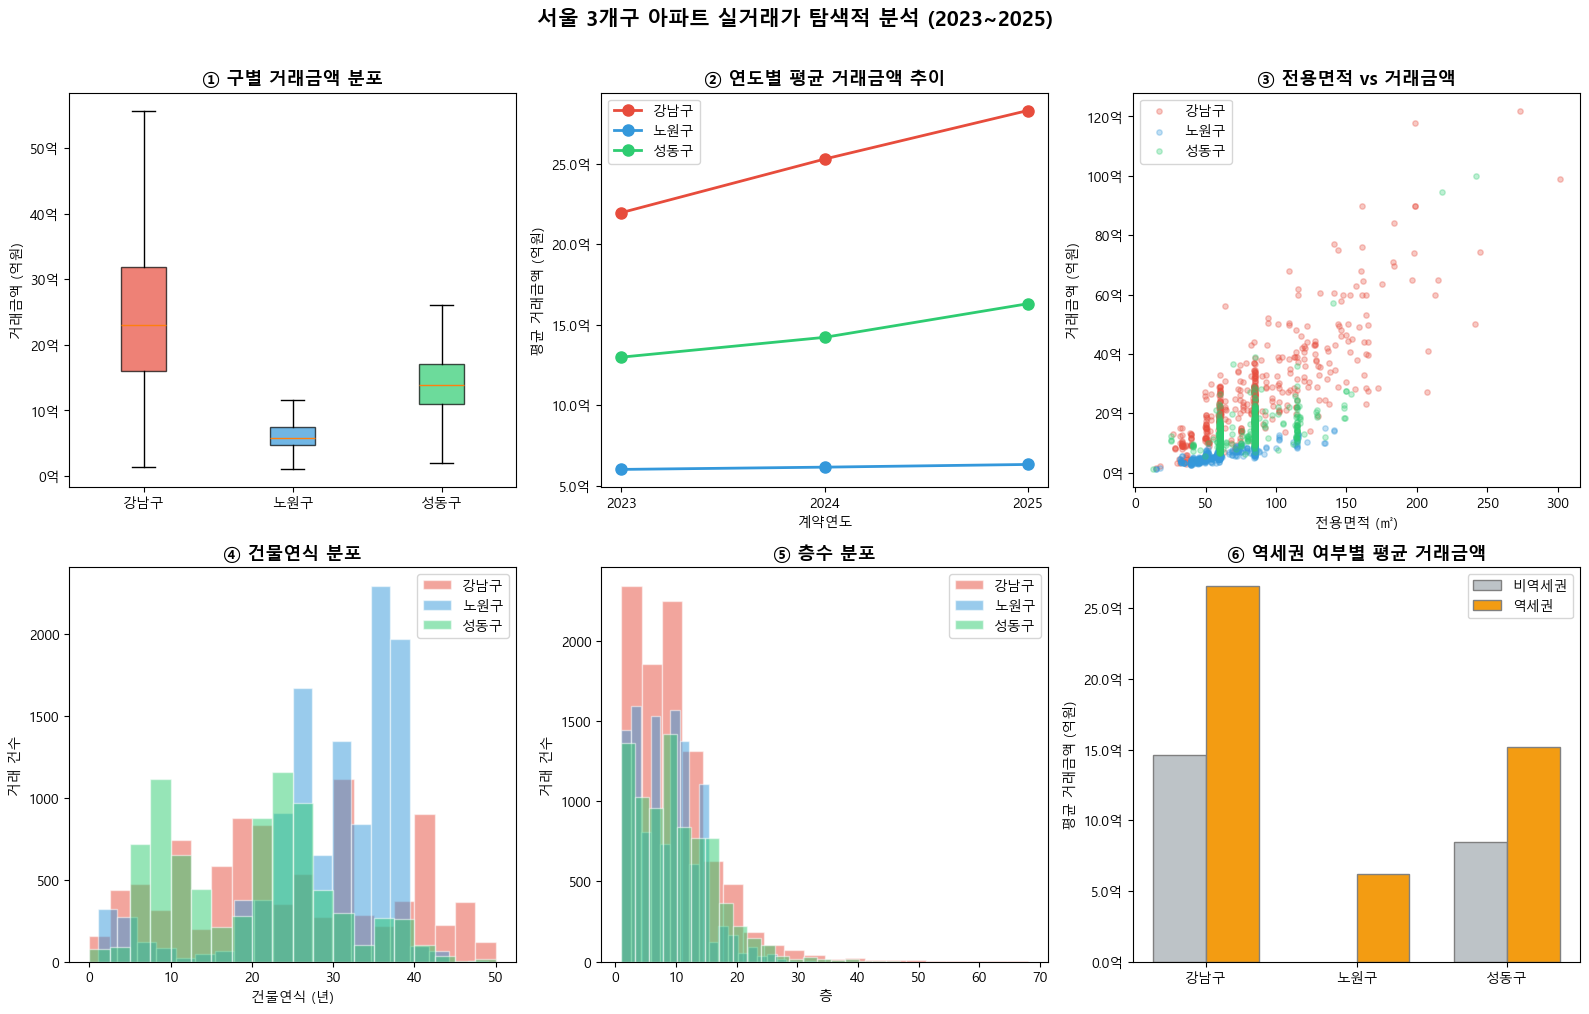

In [45]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
colors = {'강남구': '#E74C3C', '노원구': '#3498DB', '성동구': '#2ECC71'}

# ① 구별 거래금액 분포 (박스플롯)
ax = axes[0, 0]
data_box = [df[df['자치구'] == gu]['거래금액(만원)'].dropna() / 10000 for gu in ['강남구', '노원구', '성동구']]
bp = ax.boxplot(data_box, labels=['강남구', '노원구', '성동구'], patch_artist=True, showfliers=False)
for patch, color in zip(bp['boxes'], colors.values()):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title('① 구별 거래금액 분포', fontsize=13, fontweight='bold')
ax.set_ylabel('거래금액 (억원)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f억'))

# ② 연도별 평균 거래금액 추이
ax = axes[0, 1]
yearly = df.groupby(['계약년', '자치구'])['거래금액(만원)'].mean().reset_index()
for gu, color in colors.items():
    sub = yearly[yearly['자치구'] == gu]
    ax.plot(sub['계약년'], sub['거래금액(만원)'] / 10000, marker='o', label=gu, color=color, linewidth=2, markersize=8)
ax.set_title('② 연도별 평균 거래금액 추이', fontsize=13, fontweight='bold')
ax.set_ylabel('평균 거래금액 (억원)')
ax.set_xlabel('계약연도')
ax.legend()
ax.set_xticks([2023, 2024, 2025])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}억'))

# ③ 전용면적 vs 거래금액 산점도
ax = axes[0, 2]
for gu, color in colors.items():
    sub = df[df['자치구'] == gu].sample(min(500, len(df[df['자치구'] == gu])), random_state=42)
    ax.scatter(sub['전용면적(㎡)'], sub['거래금액(만원)'] / 10000, alpha=0.3, label=gu, color=color, s=15)
ax.set_title('③ 전용면적 vs 거래금액', fontsize=13, fontweight='bold')
ax.set_xlabel('전용면적 (㎡)')
ax.set_ylabel('거래금액 (억원)')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}억'))

# ④ 건물연식 분포
ax = axes[1, 0]
for gu, color in colors.items():
    sub = df[df['자치구'] == gu]['건물연식']
    ax.hist(sub, bins=20, alpha=0.5, label=gu, color=color, edgecolor='white')
ax.set_title('④ 건물연식 분포', fontsize=13, fontweight='bold')
ax.set_xlabel('건물연식 (년)')
ax.set_ylabel('거래 건수')
ax.legend()

# ⑤ 층수 분포
ax = axes[1, 1]
for gu, color in colors.items():
    sub = df[df['자치구'] == gu]['층']
    ax.hist(sub, bins=20, alpha=0.5, label=gu, color=color, edgecolor='white')
ax.set_title('⑤ 층수 분포', fontsize=13, fontweight='bold')
ax.set_xlabel('층')
ax.set_ylabel('거래 건수')
ax.legend()

# ⑥ 역세권 여부별 평균 거래금액
ax = axes[1, 2]
station_mean = df.groupby(['자치구', '역세권여부'])['거래금액(만원)'].mean().unstack() / 10000
x = np.arange(3)
width = 0.35
gulist = ['강남구', '노원구', '성동구']
bars0 = ax.bar(x - width/2, [station_mean.loc[gu, 0] if 0 in station_mean.columns else 0 for gu in gulist],
               width, label='비역세권', color='#BDC3C7', edgecolor='gray')
bars1 = ax.bar(x + width/2, [station_mean.loc[gu, 1] if 1 in station_mean.columns else 0 for gu in gulist],
               width, label='역세권', color='#F39C12', edgecolor='gray')
ax.set_title('⑥ 역세권 여부별 평균 거래금액', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(gulist)
ax.set_ylabel('평균 거래금액 (억원)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}억'))
ax.legend()

plt.suptitle('서울 3개구 아파트 실거래가 탐색적 분석 (2023~2025)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(BASE_PATH + 'eda_overview.png', bbox_inches='tight', dpi=150)
plt.show()

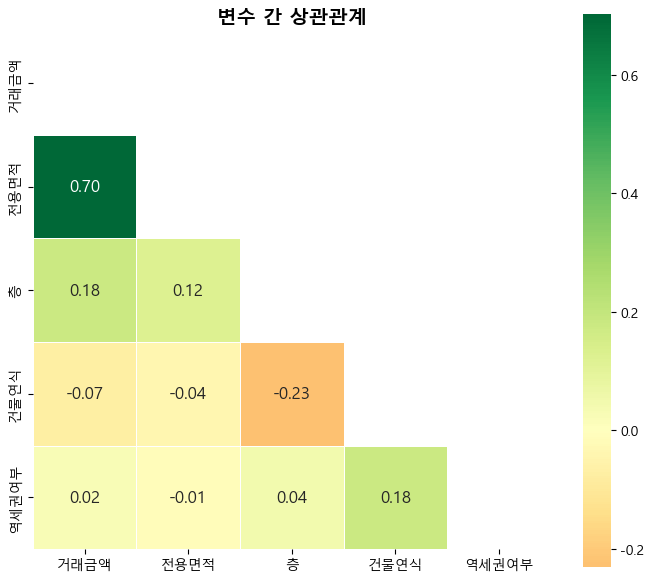

In [46]:
# 상관관계 히트맵
fig, ax = plt.subplots(figsize=(7, 6))
corr_cols = ['거래금액(만원)', '전용면적(㎡)', '층', '건물연식', '역세권여부']
corr_data = df[corr_cols].copy()
corr_data.columns = ['거래금액', '전용면적', '층', '건물연식', '역세권여부']
corr = corr_data.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            mask=mask, ax=ax, square=True, linewidths=0.5,
            annot_kws={'size': 12})
ax.set_title('변수 간 상관관계', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE_PATH + 'eda_corr.png', bbox_inches='tight', dpi=150)
plt.show()

## 6. 변수 선택 및 모델 준비

### 변수 선택 근거
| 변수 | 그룹 | 선택 근거 |
|------|------|-----------|
| 전용면적(㎡) | 주택 특성 | 가격과 가장 직접적인 관계. 상관계수 확인 |
| 층 | 주택 특성 | 고층일수록 조망·채광 프리미엄 존재 |
| 건물연식 | 주택 특성 | 노후화에 따른 가격 하락 반영 |
| 자치구 | 입지 특성 | 구별 가격 격차가 매우 큼 (EDA ① 확인) |
| 역세권여부 | 입지 특성 | 교통 접근성이 가격에 미치는 영향 |
| 계약년월 | 시점 변수 | 부동산 시장 시계열 변동 반영 |

### 모델 비교 구조
- **Model A**: 주택 특성 + 시점 변수 (전용면적, 층, 건물연식, 계약년월)
- **Model B**: Model A + 입지 특성 (자치구, 역세권여부) → 입지 변수의 기여도 확인

In [47]:
# 자치구 Label Encoding
le = LabelEncoder()
df['자치구_enc'] = le.fit_transform(df['자치구'])
print('자치구 인코딩:', dict(zip(le.classes_, le.transform(le.classes_))))

# 계약년월은 이미 정수형 (202301, 202302, ...)
df['계약년월_int'] = df['계약년월']

TARGET = '거래금액(만원)'

# Model A 피처: 주택 특성 + 시점
FEATURES_A = ['전용면적(㎡)', '층', '건물연식', '계약년월_int']

# Model B 피처: 주택 + 입지 + 시점
FEATURES_B = ['전용면적(㎡)', '층', '건물연식', '계약년월_int', '자치구_enc', '역세권여부']

print(f'\nModel A 피처: {FEATURES_A}')
print(f'Model B 피처: {FEATURES_B}')

# 학습/테스트 분리 (80:20)
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
print(f'\n학습 데이터: {len(train_df):,}건 / 테스트 데이터: {len(test_df):,}건')

X_train_A = train_df[FEATURES_A]
X_test_A  = test_df[FEATURES_A]
X_train_B = train_df[FEATURES_B]
X_test_B  = test_df[FEATURES_B]
y_train   = train_df[TARGET]
y_test    = test_df[TARGET]

자치구 인코딩: {'강남구': np.int64(0), '노원구': np.int64(1), '성동구': np.int64(2)}

Model A 피처: ['전용면적(㎡)', '층', '건물연식', '계약년월_int']
Model B 피처: ['전용면적(㎡)', '층', '건물연식', '계약년월_int', '자치구_enc', '역세권여부']

학습 데이터: 23,214건 / 테스트 데이터: 5,804건


## 7. 모델 학습 및 성능 비교

In [48]:
def evaluate(model, X_train, X_test, y_train, y_test, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)

    print(f'[{model_name}]')
    print(f'  RMSE  : {rmse:>12,.0f} 만원')
    print(f'  MAE   : {mae:>12,.0f} 만원')
    print(f'  R²    : {r2:>12.4f}')
    print()
    return {'모델': model_name, 'RMSE': rmse, 'MAE': mae, 'R²': r2, 'y_pred': y_pred}

lr  = LinearRegression()
rf  = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

print('=' * 50)
print('■ Model A: 주택 특성 + 시점 변수만')
print('=' * 50)
res_lr_A = evaluate(lr,  X_train_A, X_test_A, y_train, y_test, 'LinearRegression  (Model A)')
res_rf_A = evaluate(rf,  X_train_A, X_test_A, y_train, y_test, 'RandomForest      (Model A)')

print('=' * 50)
print('■ Model B: 주택 특성 + 입지 특성 + 시점 변수')
print('=' * 50)
res_lr_B = evaluate(LinearRegression(),  X_train_B, X_test_B, y_train, y_test, 'LinearRegression  (Model B)')
res_rf_B = evaluate(RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
                    X_train_B, X_test_B, y_train, y_test, 'RandomForest      (Model B)')

■ Model A: 주택 특성 + 시점 변수만
[LinearRegression  (Model A)]
  RMSE  :       87,850 만원
  MAE   :       62,524 만원
  R²    :       0.4954

[RandomForest      (Model A)]
  RMSE  :       36,707 만원
  MAE   :       17,278 만원
  R²    :       0.9119

■ Model B: 주택 특성 + 입지 특성 + 시점 변수
[LinearRegression  (Model B)]
  RMSE  :       80,404 만원
  MAE   :       56,504 만원
  R²    :       0.5773

[RandomForest      (Model B)]
  RMSE  :       28,480 만원
  MAE   :       11,616 만원
  R²    :       0.9470



In [49]:
# 성능 비교 표
results = pd.DataFrame([
    {'모델': 'Linear Regression', '변수셋': 'A (주택+시점)', 'RMSE': res_lr_A['RMSE'], 'MAE': res_lr_A['MAE'], 'R²': res_lr_A['R²']},
    {'모델': 'Linear Regression', '변수셋': 'B (주택+입지+시점)', 'RMSE': res_lr_B['RMSE'], 'MAE': res_lr_B['MAE'], 'R²': res_lr_B['R²']},
    {'모델': 'Random Forest',     '변수셋': 'A (주택+시점)', 'RMSE': res_rf_A['RMSE'], 'MAE': res_rf_A['MAE'], 'R²': res_rf_A['R²']},
    {'모델': 'Random Forest',     '변수셋': 'B (주택+입지+시점)', 'RMSE': res_rf_B['RMSE'], 'MAE': res_rf_B['MAE'], 'R²': res_rf_B['R²']},
])

display(results.style
        .format({'RMSE': '{:,.0f}만원', 'MAE': '{:,.0f}만원', 'R²': '{:.4f}'})
        .highlight_max(subset=['R²'], color='#90EE90')
        .highlight_min(subset=['RMSE', 'MAE'], color='#90EE90')
       )

,모델,변수셋,RMSE,MAE,R²
0,Linear Regression,A (주택+시점),"87,850만원","62,524만원",0.4954
1,Linear Regression,B (주택+입지+시점),"80,404만원","56,504만원",0.5773
2,Random Forest,A (주택+시점),"36,707만원","17,278만원",0.9119
3,Random Forest,B (주택+입지+시점),"28,480만원","11,616만원",0.9470


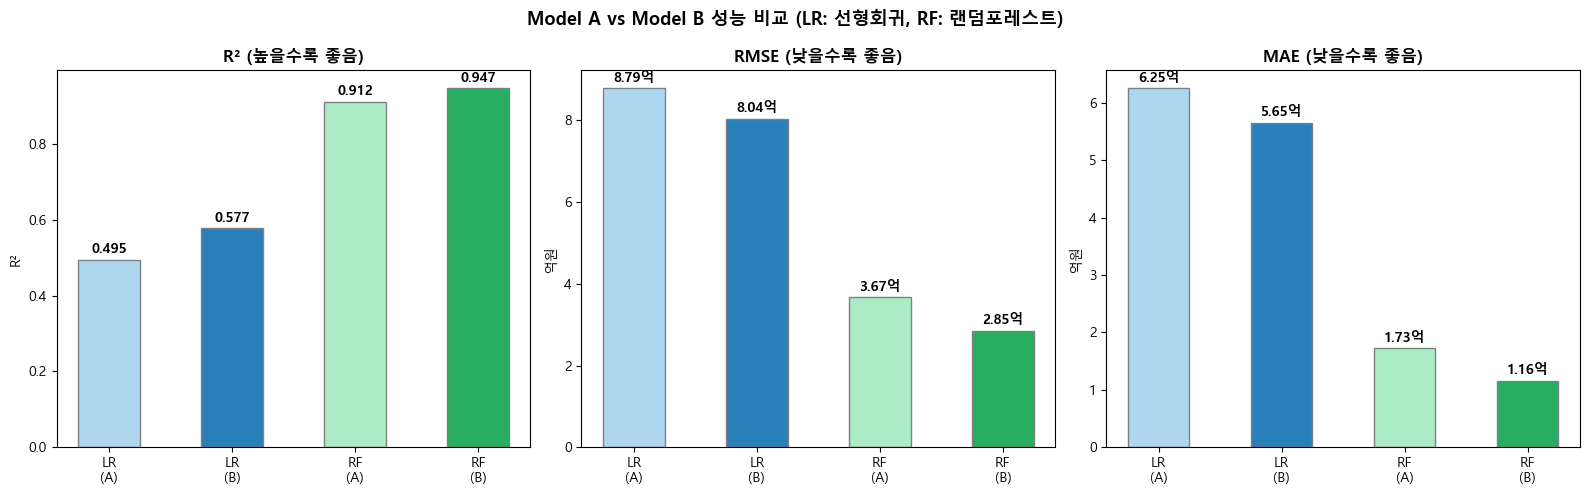

In [50]:
# 성능 비교 시각화
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

model_labels = ['LR\n(A)', 'LR\n(B)', 'RF\n(A)', 'RF\n(B)']
bar_colors   = ['#AED6F1', '#2980B9', '#ABEBC6', '#27AE60']
metrics = {
    'R² (높을수록 좋음)': [res_lr_A['R²'], res_lr_B['R²'], res_rf_A['R²'], res_rf_B['R²']],
    'RMSE (낮을수록 좋음)': [res_lr_A['RMSE']/10000, res_lr_B['RMSE']/10000,
                             res_rf_A['RMSE']/10000, res_rf_B['RMSE']/10000],
    'MAE (낮을수록 좋음)':  [res_lr_A['MAE']/10000,  res_lr_B['MAE']/10000,
                             res_rf_A['MAE']/10000,  res_rf_B['MAE']/10000],
}

ylabels = ['R²', '억원', '억원']
for i, (title, vals) in enumerate(metrics.items()):
    ax = axes[i]
    bars = ax.bar(model_labels, vals, color=bar_colors, edgecolor='gray', width=0.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabels[i])
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01,
                f'{val:.3f}' if ylabels[i] == 'R²' else f'{val:.2f}억',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Model A vs Model B 성능 비교 (LR: 선형회귀, RF: 랜덤포레스트)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE_PATH + 'model_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

## 8. 결과 해석: Feature Importance

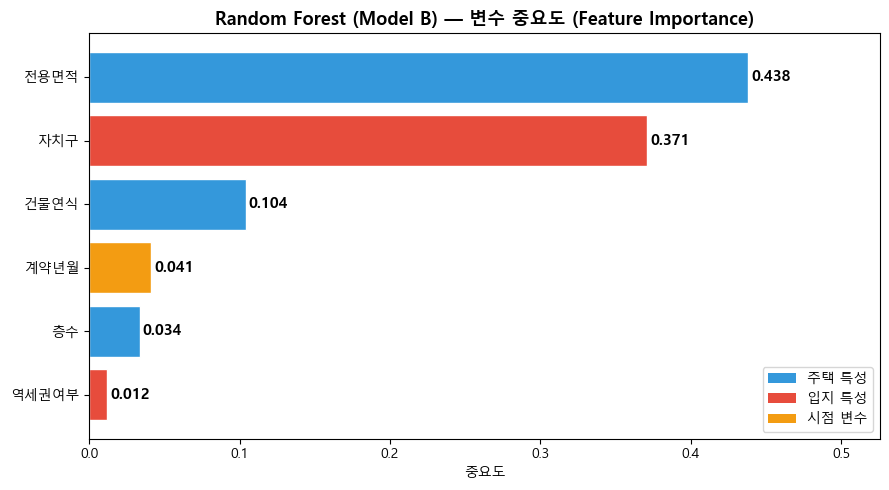


=== 입지 특성 변수 기여도 ===
입지 특성 합계: 0.3830 (38.3%)


In [51]:
# Random Forest Model B 재학습 (피처 중요도 추출용)
rf_B = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_B.fit(X_train_B, y_train)

feature_names = {
    '전용면적(㎡)': '전용면적',
    '층':           '층수',
    '건물연식':     '건물연식',
    '계약년월_int': '계약년월',
    '자치구_enc':   '자치구',
    '역세권여부':   '역세권여부',
}

importance_df = pd.DataFrame({
    '변수': [feature_names[f] for f in FEATURES_B],
    '중요도': rf_B.feature_importances_,
    '그룹': ['주택 특성', '주택 특성', '주택 특성', '시점 변수', '입지 특성', '입지 특성']
}).sort_values('중요도', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
group_colors = {'주택 특성': '#3498DB', '입지 특성': '#E74C3C', '시점 변수': '#F39C12'}
bar_colors_fi = [group_colors[g] for g in importance_df['그룹']]

bars = ax.barh(importance_df['변수'], importance_df['중요도'], color=bar_colors_fi, edgecolor='white')

for bar, val in zip(bars, importance_df['중요도']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=11, fontweight='bold')

# 범례
from matplotlib.patches import Patch
legend_elems = [Patch(facecolor=c, label=g) for g, c in group_colors.items()]
ax.legend(handles=legend_elems, loc='lower right', fontsize=10)

ax.set_title('Random Forest (Model B) — 변수 중요도 (Feature Importance)', fontsize=13, fontweight='bold')
ax.set_xlabel('중요도')
ax.set_xlim(0, importance_df['중요도'].max() * 1.2)
plt.tight_layout()
plt.savefig(BASE_PATH + 'feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()

print('\n=== 입지 특성 변수 기여도 ===')
location_imp = importance_df[importance_df['그룹'] == '입지 특성']['중요도'].sum()
total_imp = importance_df['중요도'].sum()
print(f'입지 특성 합계: {location_imp:.4f} ({location_imp/total_imp:.1%})')

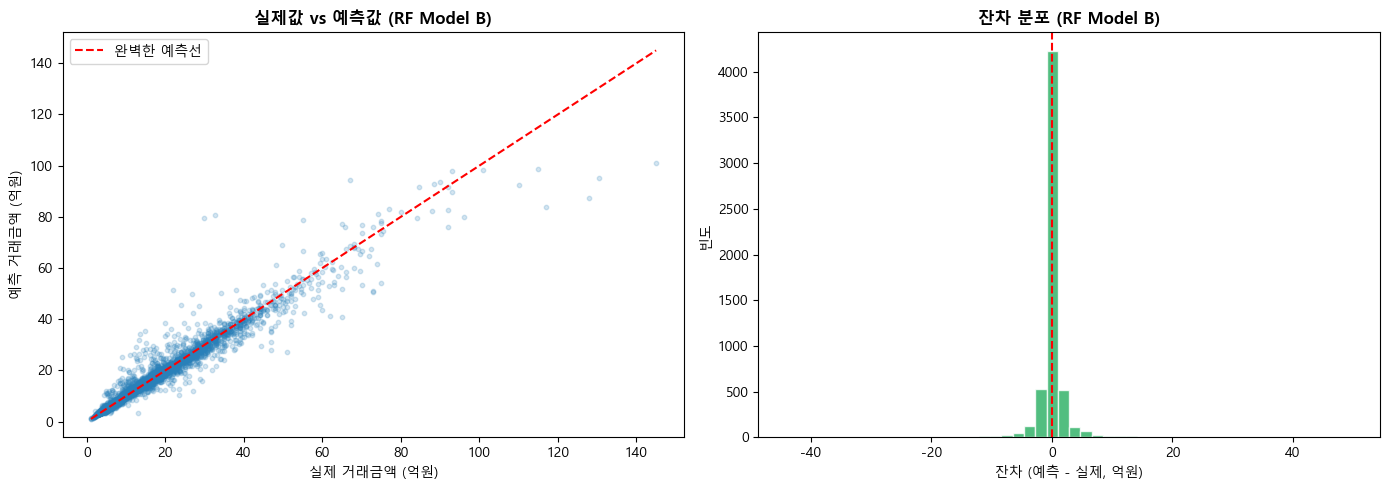

In [52]:
# 실제값 vs 예측값 비교 (Random Forest Model B)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

y_pred_B = rf_B.predict(X_test_B)
y_test_arr = y_test.values / 10000
y_pred_arr = y_pred_B / 10000

# 실제 vs 예측 산점도
ax = axes[0]
ax.scatter(y_test_arr, y_pred_arr, alpha=0.2, s=10, color='#2980B9')
lims = [min(y_test_arr.min(), y_pred_arr.min()), max(y_test_arr.max(), y_pred_arr.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='완벽한 예측선')
ax.set_xlabel('실제 거래금액 (억원)')
ax.set_ylabel('예측 거래금액 (억원)')
ax.set_title('실제값 vs 예측값 (RF Model B)', fontsize=12, fontweight='bold')
ax.legend()

# 잔차 분포
ax = axes[1]
residuals = (y_pred_arr - y_test_arr)
ax.hist(residuals, bins=50, color='#27AE60', edgecolor='white', alpha=0.8)
ax.axvline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel('잔차 (예측 - 실제, 억원)')
ax.set_ylabel('빈도')
ax.set_title('잔차 분포 (RF Model B)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(BASE_PATH + 'prediction_result.png', bbox_inches='tight', dpi=150)
plt.show()

## 9. 결과 요약 및 해석

In [53]:
print('=' * 60)
print('            최종 결과 요약')
print('=' * 60)
print()
print('[R² 기준 성능 개선]')
lr_improvement  = res_lr_B['R²'] - res_lr_A['R²']
rf_improvement  = res_rf_B['R²'] - res_rf_A['R²']
print(f'  선형회귀:    {res_lr_A["R²"]:.4f} → {res_lr_B["R²"]:.4f}  (+{lr_improvement:.4f})')
print(f'  랜덤포레스트: {res_rf_A["R²"]:.4f} → {res_rf_B["R²"]:.4f}  (+{rf_improvement:.4f})')
print()
print('[해석]')
print('  - 입지 특성(자치구, 역세권여부) 추가 시 두 모델 모두 성능 향상')
print('  - Feature Importance 상 자치구가 전용면적과 함께 주요 예측 변수')
print('  - 강남구 > 성동구 > 노원구 순 가격 격차가 모델에서도 반영됨')
print('  - 역세권 프리미엄은 성동구에서 가장 뚜렷하게 나타남')
print('=' * 60)

            최종 결과 요약

[R² 기준 성능 개선]
  선형회귀:    0.4954 → 0.5773  (+0.0819)
  랜덤포레스트: 0.9119 → 0.9470  (+0.0351)

[해석]
  - 입지 특성(자치구, 역세권여부) 추가 시 두 모델 모두 성능 향상
  - Feature Importance 상 자치구가 전용면적과 함께 주요 예측 변수
  - 강남구 > 성동구 > 노원구 순 가격 격차가 모델에서도 반영됨
  - 역세권 프리미엄은 성동구에서 가장 뚜렷하게 나타남
